In [1]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import VarianceThreshold

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    LSTM,
    Dropout,
    Bidirectional
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam

In [2]:
# ==========================================================
# RANDOM SEED
# ==========================================================

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# ==========================================================
# DATASET PATH
# MODIFY THIS
# ==========================================================

DATA_PATH = r"C:\Projects\Aircraft_Fault_Detection\Data"

# ==========================================================
# FILE PATHS
# ==========================================================

TRAIN_PATH = os.path.join(
    DATA_PATH,
    "train_FD004.txt"
)

TEST_PATH = os.path.join(
    DATA_PATH,
    "test_FD004.txt"
)

RUL_PATH = os.path.join(
    DATA_PATH,
    "RUL_FD004.txt"
)

In [4]:
# ==========================================================
# CHECK FILES
# ==========================================================

print("Checking dataset files...\n")
print(TRAIN_PATH, os.path.exists(TRAIN_PATH))
print(TEST_PATH, os.path.exists(TEST_PATH))
print(RUL_PATH, os.path.exists(RUL_PATH))

Checking dataset files...

C:\Projects\Aircraft_Fault_Detection\Data\train_FD004.txt True
C:\Projects\Aircraft_Fault_Detection\Data\test_FD004.txt True
C:\Projects\Aircraft_Fault_Detection\Data\RUL_FD004.txt True


In [5]:
# ==========================================================
# COLUMN NAMES
# ==========================================================

columns = (
    ['engine_id', 'cycle']
    + [f'op_setting_{i}' for i in range(1,4)]
    + [f'sensor_{i}' for i in range(1,22)]
)
print(columns)

['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [6]:
# ==========================================================
# LOAD DATA
# ==========================================================

train_df = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
)
7
test_df = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
)

rul_df = pd.read_csv(
    RUL_PATH,
    header=None,
)

In [7]:
print(train_df.shape)
print(test_df.shape)
print(rul_df.shape)

(61249, 26)
(41214, 26)
(248, 1)


In [8]:
# ==========================================================
# REMOVE EXTRA COLUMNS
# ==========================================================

train_df = train_df.iloc[:, :26]
test_df = test_df.iloc[:, :26]

In [9]:
# ==========================================================
# ASSIGN COLUMN NAMES
# ==========================================================

train_df.columns = columns
test_df.columns = columns

In [10]:
# ==========================================================
# SORT VALUES
# ==========================================================

train_df = train_df.sort_values(
    ['engine_id', 'cycle']
).reset_index(drop=True)

test_df = test_df.sort_values(
    ['engine_id', 'cycle']
).reset_index(drop=True)

In [11]:
# ==========================================================
# CREATE TRAIN RUL
# ==========================================================

max_cycle = (
    train_df.groupby('engine_id')['cycle']
    .max()
    .reset_index() # Creates a new index column, the older index engine_id will be now created as the first column 
)

# Updating the column name from cycle to max_cycle
max_cycle.columns = [
    'engine_id',
    'max_cycle'
]

train_df = train_df.merge(
    max_cycle,
    on='engine_id'
)

train_df['RUL'] = (
    train_df['max_cycle']
    - train_df['cycle']
)

In [12]:
# ==========================================================
# CREATE TEST RUL
# ==========================================================

test_max = (
    test_df.groupby('engine_id')['cycle']
    .max()
    .reset_index() # Creates a new index column, the older index engine_id will be now created as the first column
)

# Updating the column name from cycle to max_cycle
test_max.columns = [
    'engine_id',
    'max_cycle'
]

rul_df.columns = ['more_cycles']

test_max['final_cycle'] = (
    test_max['max_cycle']
    + rul_df['more_cycles']
)

test_df = test_df.merge(
    test_max[['engine_id', 'final_cycle']],
    on='engine_id'
)

test_df['RUL'] = (
    test_df['final_cycle']
    - test_df['cycle']
)

In [13]:
# ==========================================================
# CREATE LABELS
# 1 -> FAILURE RISK
# 0 -> HEALTHY
# ==========================================================

FAILURE_THRESHOLD = 30

train_df['label'] = np.where(
    train_df['RUL'] <= FAILURE_THRESHOLD,
    1,
    0
)

test_df['label'] = np.where(
    test_df['RUL'] <= FAILURE_THRESHOLD,
    1,
    0
)

In [14]:
from sklearn.feature_selection import VarianceThreshold

feature_cols = [col for col in train_df.columns if col.startswith("sensor") or col.startswith("op_setting")]

variance_df = (
    train_df[feature_cols]
    .var()
    .sort_values()
    .reset_index()
)

variance_df.columns = [
    "Feature",
    "Variance"
]
Threshold = 0.01

print(variance_df)

         Feature       Variance
0      sensor_16       0.000022
1      sensor_10       0.016302
2   op_setting_2       0.096537
3      sensor_15       0.563061
4      sensor_11      10.520237
5       sensor_5      13.125202
6      sensor_19      28.830710
7       sensor_6      29.637316
8      sensor_21      35.553759
9      sensor_20      98.731968
10  op_setting_3     203.118191
11  op_setting_1     218.469733
12      sensor_1     698.906067
13     sensor_17     773.300629
14      sensor_2    1394.473263
15     sensor_14    7339.442015
16      sensor_3   11271.558809
17      sensor_4   14239.073899
18     sensor_13   16434.691116
19     sensor_12   19176.463675
20      sensor_8   21126.111710
21     sensor_18   21162.245693
22      sensor_7   21573.795950
23      sensor_9  113520.171620


In [15]:
# ==========================================================
# REMOVE LOW VARIANCE / NOISY SENSORS
# ==========================================================

drop_sensors = [
    'sensor_10',
    'sensor_16',
]

train_df.drop(
    columns=drop_sensors,
    inplace=True
)

test_df.drop(
    columns=drop_sensors,
    inplace=True
)

In [16]:
# ==========================================================
# FEATURE COLUMNS
# ==========================================================

feature_cols = [
    col for col in train_df.columns
    if (
        'sensor' in col
        or 'op_setting' in col
    )
]

print("\nNumber of Features:", len(feature_cols))


Number of Features: 22


In [17]:
from sklearn.ensemble import RandomForestClassifier
X_rf = train_df[feature_cols]
y_rf = train_df["label"]

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_rf, y_rf)

RandomForestClassifier(max_depth=15, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [18]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(importance_df)

         Feature  Importance
14     sensor_13    0.205333
12     sensor_11    0.116624
16     sensor_15    0.100372
15     sensor_14    0.092248
6       sensor_4    0.088536
11      sensor_9    0.050706
10      sensor_8    0.046943
13     sensor_12    0.043851
5       sensor_3    0.038416
9       sensor_7    0.036452
4       sensor_2    0.036428
17     sensor_17    0.034596
21     sensor_21    0.033611
20     sensor_20    0.031796
8       sensor_6    0.015737
0   op_setting_1    0.014332
1   op_setting_2    0.007254
18     sensor_18    0.002522
3       sensor_1    0.002084
7       sensor_5    0.001592
19     sensor_19    0.000326
2   op_setting_3    0.000240


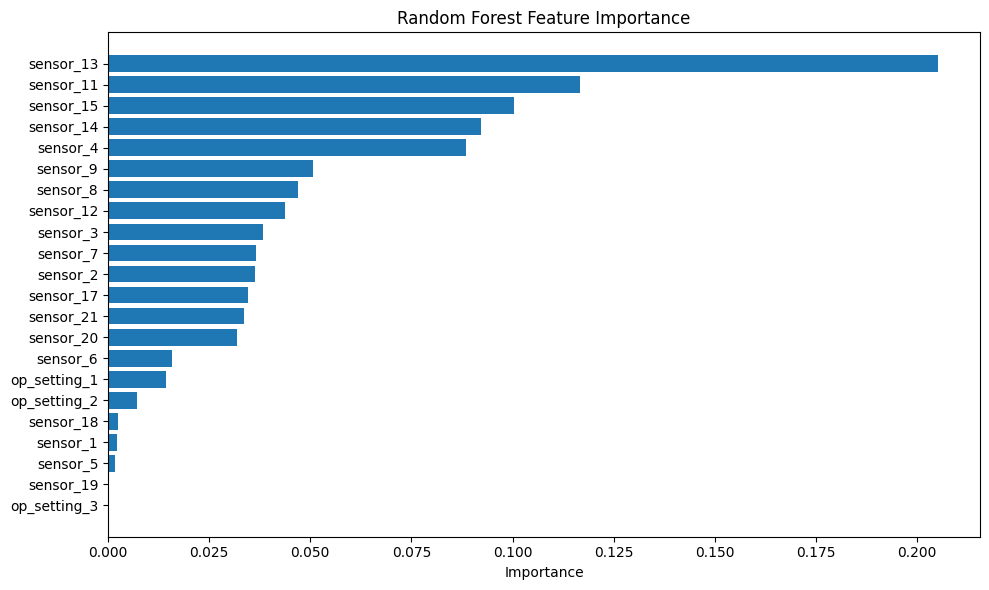

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"][:][::-1],
    importance_df["Importance"][:][::-1]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [20]:
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

selected_features = importance_df.head(18)["Feature"].tolist()
display(selected_features)

['sensor_13',
 'sensor_11',
 'sensor_15',
 'sensor_14',
 'sensor_4',
 'sensor_9',
 'sensor_8',
 'sensor_12',
 'sensor_3',
 'sensor_7',
 'sensor_2',
 'sensor_17',
 'sensor_21',
 'sensor_20',
 'sensor_6',
 'op_setting_1',
 'op_setting_2',
 'sensor_18']

In [21]:
train_df = train_df[
    ["engine_id", "cycle"] +
    selected_features +
    ["RUL", "label"]
]

test_df = test_df[
    ["engine_id", "cycle"] +
    selected_features +
    ["RUL", "label"]
]

In [22]:
feature_cols = [
    col for col in train_df.columns
    if col not in [
        "engine_id",
        "cycle",
        "RUL",
        "label"
    ]
]
print(feature_cols)

['sensor_13', 'sensor_11', 'sensor_15', 'sensor_14', 'sensor_4', 'sensor_9', 'sensor_8', 'sensor_12', 'sensor_3', 'sensor_7', 'sensor_2', 'sensor_17', 'sensor_21', 'sensor_20', 'sensor_6', 'op_setting_1', 'op_setting_2', 'sensor_18']


In [23]:
# ==========================================================
# STANDARDIZATION
# ==========================================================

scaler = StandardScaler()

train_df[feature_cols] = scaler.fit_transform(
    train_df[feature_cols]
)

test_df[feature_cols] = scaler.transform(
    test_df[feature_cols]
)

In [24]:
# ==========================================================
# CREATE SEQUENCES
# ==========================================================

SEQ_LEN = 30

def create_sequences(df, seq_len, feature_cols):

    X = []
    y = []

    for engine_id in df['engine_id'].unique():

        engine_data = df[
            df['engine_id'] == engine_id
        ]

        feature_array = engine_data[
            feature_cols
        ].values

        label_array = engine_data[
            'label'
        ].values

        for i in range(
            len(engine_data) - seq_len
        ):

            X.append(
                feature_array[i:i+seq_len]
            )

            y.append(
                label_array[i+seq_len]
            )

    return np.array(X), np.array(y)

In [25]:
# ==========================================================
# CREATE TRAIN & TEST DATA
# ==========================================================

X_train, y_train = create_sequences(
    train_df,
    SEQ_LEN,
    feature_cols
)

X_test, y_test = create_sequences(
    test_df,
    SEQ_LEN,
    feature_cols
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (53779, 30, 18)
Test Shape: (33844, 30, 18)


In [26]:
# ==========================================================
# CLASS BALANCING
# ==========================================================

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print("\nClass Weights:")
print(class_weights)


Class Weights:
{0: 0.5837928788536692, 1: 3.4835470915921753}


In [27]:
# ==========================================================
# BUILD MODEL
# ==========================================================

model = Sequential([

    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        ),
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    ),

    Dropout(0.3),

    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        )
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.2),

    Dense(
        1,
        activation='sigmoid'
    )
])

c:\Users\ponla\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
# ==========================================================
# COMPILE MODEL
# ==========================================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [29]:
# ==========================================================
# MODEL SUMMARY
# ==========================================================

print("\nModel Summary:")
print(model.summary())


Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       150,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,201 (1.23 MB)

 Trainable params: 323,201 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

None


In [30]:
# ==========================================================
# CALLBACKS
# ==========================================================

early_stop = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

In [43]:
# ==========================================================
# TRAIN MODEL
# ==========================================================

history = model.fit(

    X_train,
    y_train,

    validation_split=0.1,

    epochs=20,

    batch_size=256,

    class_weight=class_weights,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 58s 302ms/step - accuracy: 0.9442 - auc: 0.9902 - loss: 0.1129 - val_accuracy: 0.9574 - val_auc: 0.9778 - val_loss: 0.1138 - learning_rate: 5.0000e-04
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 56s 295ms/step - accuracy: 0.9482 - auc: 0.9914 - loss: 0.1041 - val_accuracy: 0.9550 - val_auc: 0.9712 - val_loss: 0.1315 - learning_rate: 5.0000e-04
Epoch 3/20
189/190 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9492 - auc: 0.9917 - loss: 0.1037
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
190/190 ━━━━━━━━━━━━━━━━━━━━ 58s 304ms/step - accuracy: 0.9509 - auc: 0.9920 - loss: 0.0993 - val_accuracy: 0.9533 - val_auc: 0.9659 - val_loss: 0.1523 - learning_rate: 5.0000e-04
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 56s 292ms/step - accuracy: 0.9576 - auc: 0.9940 - loss: 0.0850 - val_accuracy: 0.9641 - val_auc: 0.9804 - val_loss: 0.1028 - learning_rate: 2.5000e-04
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 56s 293ms/step - accuracy: 0.

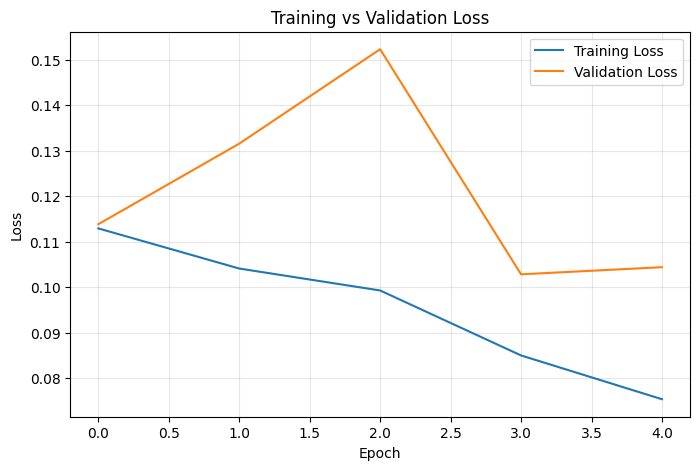

In [44]:
# ==========================================================
# TRAINING PLOTS
# ==========================================================

plt.figure(figsize=(8,5))
plt.plot(
    history.history['loss'],
    label='Training Loss'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [45]:
# ==========================================================
# PREDICTION PROBABILITIES
# ==========================================================

y_prob = model.predict(X_test).ravel()

1058/1058 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step


In [46]:
# ==========================================================
# FIND BEST THRESHOLD
# ==========================================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

f1_scores = (
    2 * precision * recall
) / (
    precision + recall + 1e-8
)

best_idx = np.argmax(
    f1_scores[:-1]
)

best_threshold = thresholds[best_idx]

print("\nBest Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_idx])


Best Threshold: 0.5138598
Best F1 Score: 0.6132264479959519


In [47]:
# ==========================================================
# FINAL PREDICTIONS
# ==========================================================

y_pred = np.where(
    y_prob >= best_threshold,
    1,
    0
)

In [48]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     32980
           1       0.54      0.71      0.61       864

    accuracy                           0.98     33844
   macro avg       0.77      0.85      0.80     33844
weighted avg       0.98      0.98      0.98     33844



In [49]:
# ==========================================================
# FINAL F1 SCORE
# ==========================================================

final_f1 = f1_score(
    y_test,
    y_pred
)

print("\nFinal F1 Score:", final_f1)


Final F1 Score: 0.6132264529058116


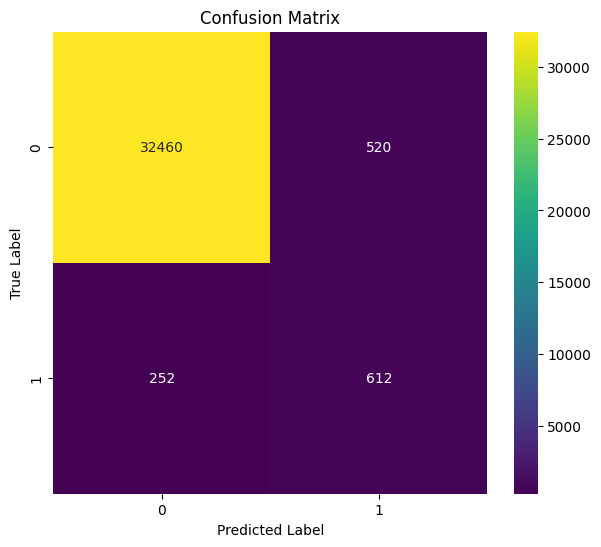

In [50]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

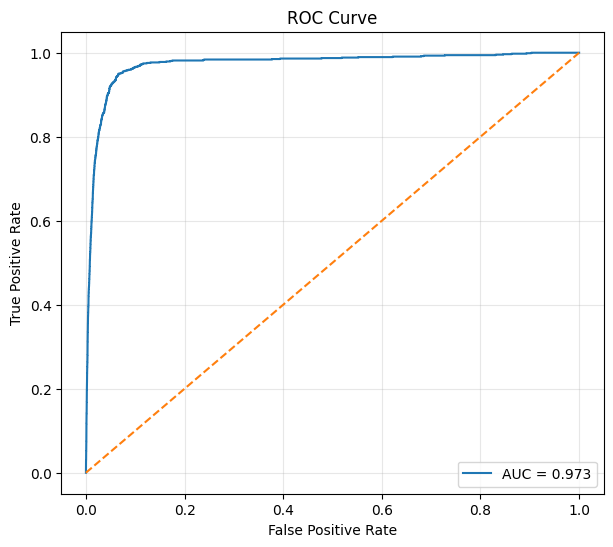


ROC-AUC: 0.973388052242661


In [51]:
# ==========================================================
# ROC CURVE
# ==========================================================

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)
roc_auc = auc(
    fpr,
    tpr
)
plt.figure(figsize=(7,6))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)
plt.plot(
    [0,1],
    [0,1],
    '--'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("\nROC-AUC:", roc_auc)

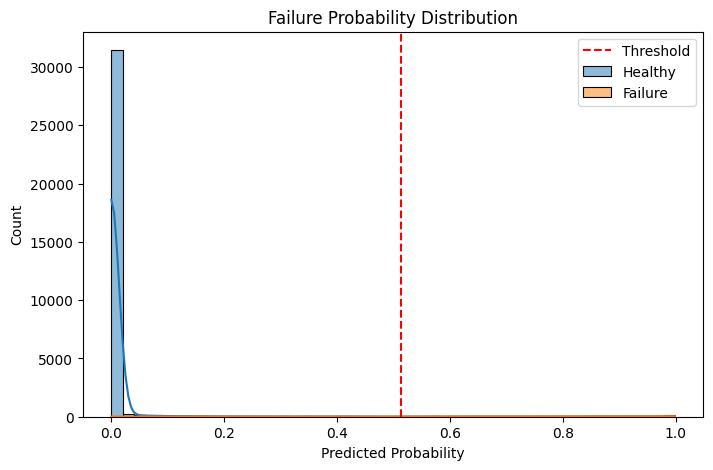

In [52]:
# ==========================================================
# FAILURE PROBABILITY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))
sns.histplot(
    y_prob[y_test == 0],
    bins=50,
    label='Healthy',
    kde=True
)
sns.histplot(
    y_prob[y_test == 1],
    bins=50,
    label='Failure',
    kde=True
)
plt.axvline(
    best_threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)
plt.title("Failure Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

In [55]:
# ==========================================================
# SAVE MODEL
# ==========================================================

model.save(
    r"C:\Projects\Aircraft_Fault_Detection\Models\best_fd004_bilstm_classifier.keras"
)
print("\nModel Saved Successfully!")


Model Saved Successfully!


In [54]:
# ==========================================================
# SAMPLE LIVE PREDICTION
# ==========================================================

sample = X_test[0:1]

sample_prob = model.predict(sample)[0][0]

print("\nFailure Probability:")
print(sample_prob)

if sample_prob >= best_threshold:
    print("FAILURE RISK DETECTED")
else:
    print("ENGINE IS HEALTHY")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

Failure Probability:
2.5057036e-05
ENGINE IS HEALTHY
